1. Data Collection

In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

internal = pd.read_excel("Internal_Bank_Dataset.xlsx")
external = pd.read_excel("External_Cibil_Dataset.xlsx")

print(internal.shape)
print(external.shape)

(51336, 26)
(51336, 62)


2. Data Understanding

In [163]:
internal.head()
external.head()

internal.info()
external.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51336 entries, 0 to 51335
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   PROSPECTID            51336 non-null  int64  
 1   Total_TL              51336 non-null  int64  
 2   Tot_Closed_TL         51336 non-null  int64  
 3   Tot_Active_TL         51336 non-null  int64  
 4   Total_TL_opened_L6M   51336 non-null  int64  
 5   Tot_TL_closed_L6M     51336 non-null  int64  
 6   pct_tl_open_L6M       51336 non-null  float64
 7   pct_tl_closed_L6M     51336 non-null  float64
 8   pct_active_tl         51336 non-null  float64
 9   pct_closed_tl         51336 non-null  float64
 10  Total_TL_opened_L12M  51336 non-null  int64  
 11  Tot_TL_closed_L12M    51336 non-null  int64  
 12  pct_tl_open_L12M      51336 non-null  float64
 13  pct_tl_closed_L12M    51336 non-null  float64
 14  Tot_Missed_Pmnt       51336 non-null  int64  
 15  Auto_TL            

3. Data Merge

In [164]:
df = internal.merge(
    external,
    on="PROSPECTID",
    how="inner"
)

print(df.shape)

(51336, 87)


4. Target Creation

In [165]:
df["target_default"] = df["Approved_Flag"].map({
    "P1":0,
    "P2":0,
    "P3":1,
    "P4":1
})

In [166]:
df["target_default"].value_counts()
df["target_default"].value_counts(normalize=True)*100

target_default
0    74.026025
1    25.973975
Name: proportion, dtype: float64

5. Missing Value Analysis

In [184]:
(df == -99999).sum().sort_values(ascending=False)

PROSPECTID             0
Total_TL               0
Tot_Closed_TL          0
Tot_Active_TL          0
Total_TL_opened_L6M    0
                      ..
last_prod_enq2         0
first_prod_enq2        0
Credit_Score           0
Approved_Flag          0
target_default         0
Length: 88, dtype: int64

In [187]:
df.isnull().sum().sort_values(ascending=False)

CC_utilization                  47636
PL_utilization                  44435
time_since_recent_deliquency    35949
time_since_first_deliquency     35949
max_delinquency_level           35949
                                ...  
last_prod_enq2                      0
first_prod_enq2                     0
Credit_Score                        0
Approved_Flag                       0
target_default                      0
Length: 88, dtype: int64

6. Data Cleaning

In [188]:
#Replace special missing values:
df.replace(-99999, np.nan, inplace=True)

In [189]:
#Fill enquiries:
df["tot_enq"] = df["tot_enq"].fillna(
    df["tot_enq"].median()
)

df["enq_L3m"] = df["enq_L3m"].fillna(
    df["enq_L3m"].median()
)

In [190]:
#Fill TL age:
df["Age_Oldest_TL"] = df["Age_Oldest_TL"].fillna(
    df["Age_Oldest_TL"].median()
)

df["Age_Newest_TL"] = df["Age_Newest_TL"].fillna(
    df["Age_Newest_TL"].median()
)

7. EDA

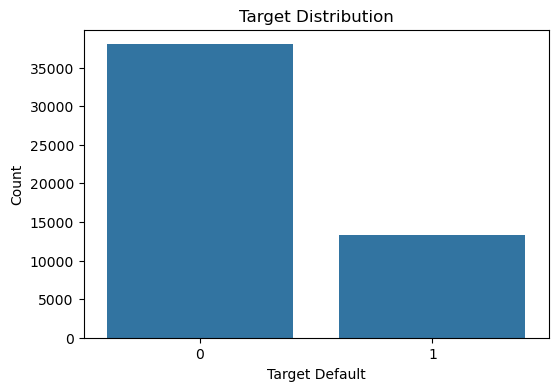

In [191]:
#1. Target Distribution
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(
    x="target_default",
    data=df
)

plt.title("Target Distribution")
plt.xlabel("Target Default")
plt.ylabel("Count")

plt.show()

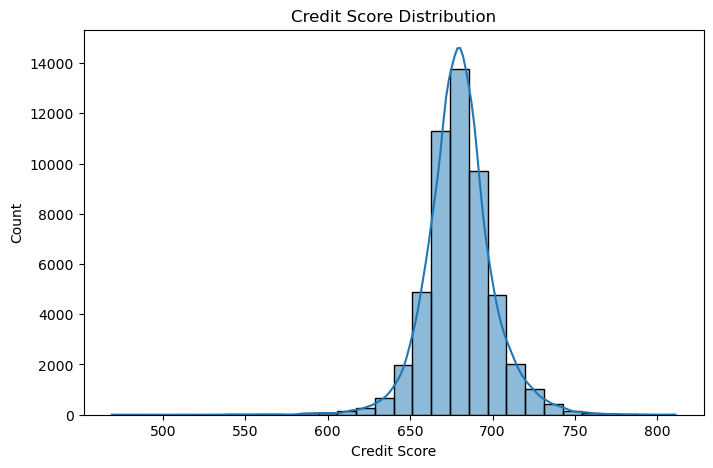

In [192]:
#2. Credit Score Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df["Credit_Score"],
    bins=30,
    kde=True
)

plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Count")

plt.show()

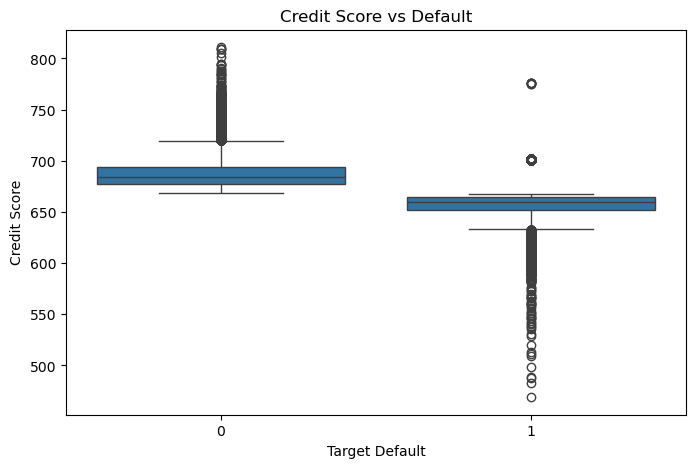

In [193]:
#3. Target vs Credit Score Boxplot
plt.figure(figsize=(8,5))

sns.boxplot(
    x="target_default",
    y="Credit_Score",
    data=df
)

plt.title("Credit Score vs Default")
plt.xlabel("Target Default")
plt.ylabel("Credit Score")

plt.show()

In [194]:
#4. Correlation Heatmap
corr_cols = [

"Credit_Score",
"NETMONTHLYINCOME",

"Total_TL",
"Tot_Active_TL",

"Tot_Missed_Pmnt",

"num_times_delinquent",
"num_times_30p_dpd",
"num_times_60p_dpd",

"tot_enq",
"enq_L3m",

"CC_utilization",
"PL_utilization",

"target_default"

]

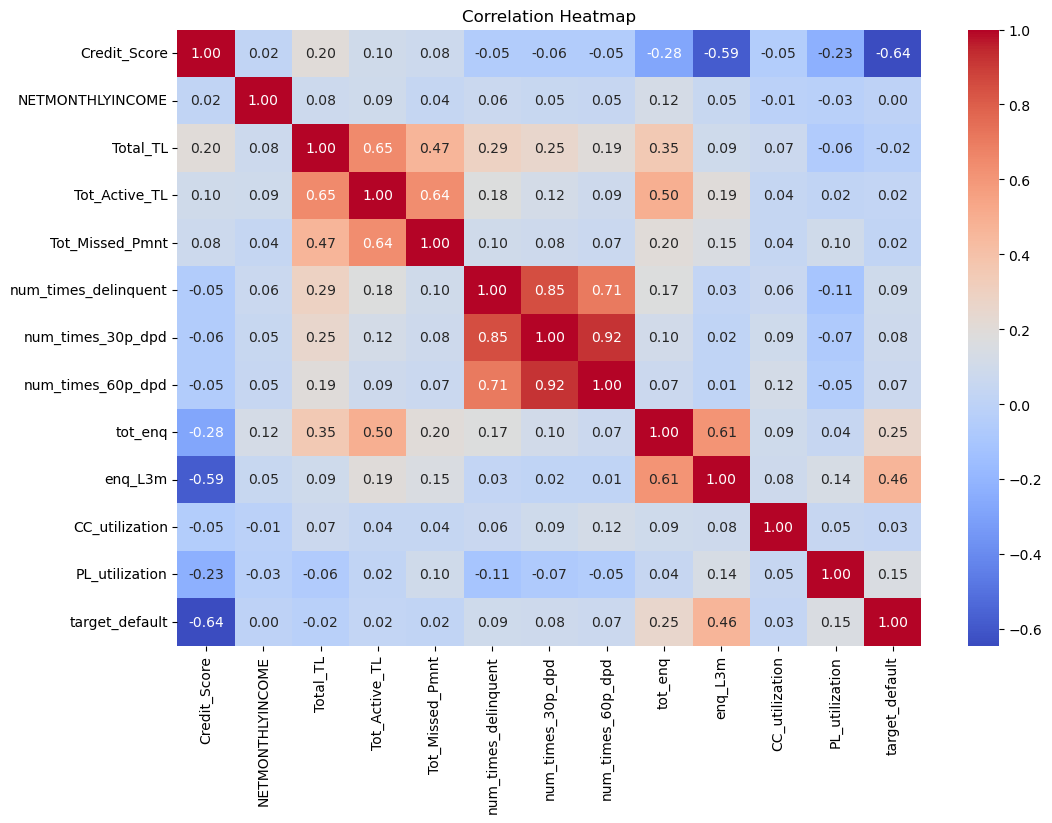

In [195]:
plt.figure(figsize=(12,8))

corr = df[corr_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

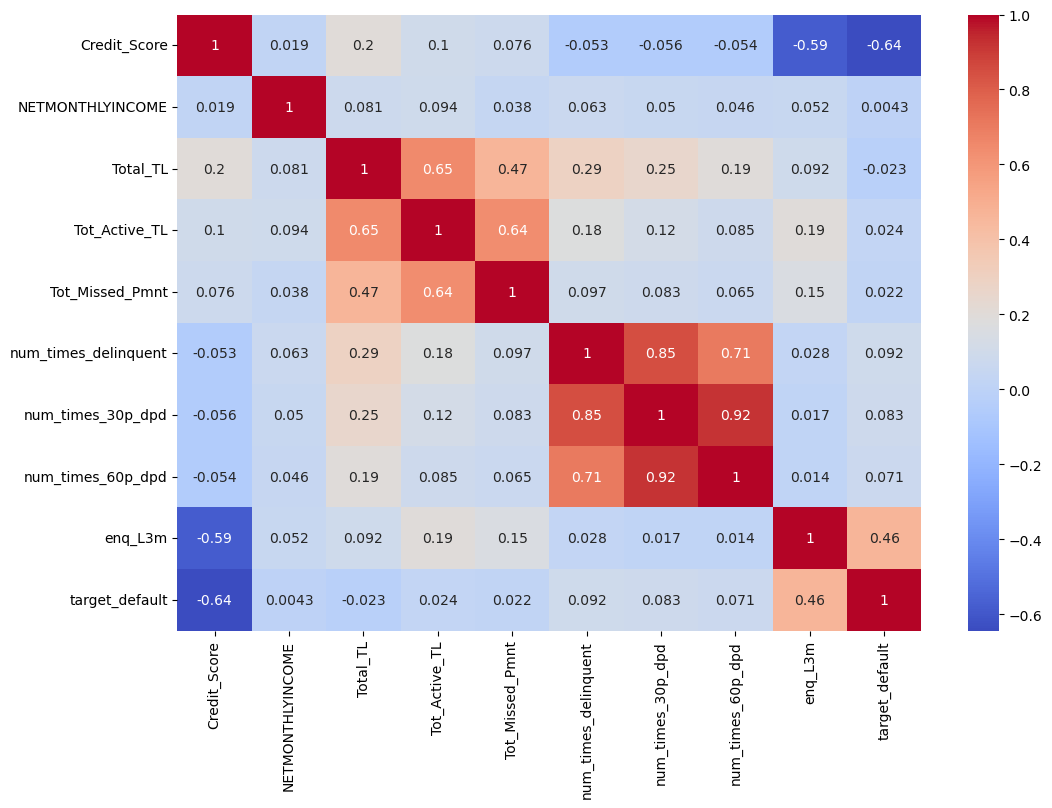

In [196]:
plt.figure(figsize=(12,8))
corr_cols = [
"Credit_Score",
"NETMONTHLYINCOME",
"Total_TL",
"Tot_Active_TL",
"Tot_Missed_Pmnt",
"num_times_delinquent",
"num_times_30p_dpd",
"num_times_60p_dpd",
"enq_L3m",
"target_default"
]

corr = df[corr_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.show()

8. Feature Engineering

In [197]:
df["delinq_ratio"] = (
    df["num_times_delinquent"]
    /
    (df["Total_TL"] + 1)
)

df["enq_intensity"] = (
    df["tot_enq"]
    /
    (df["Total_TL"] + 1)
)

In [198]:
corr = df[
[
"delinq_ratio",
"enq_intensity",
"target_default"
]
].corr()

print(corr)

                delinq_ratio  enq_intensity  target_default
delinq_ratio        1.000000       0.037593        0.140034
enq_intensity       0.037593       1.000000        0.348737
target_default      0.140034       0.348737        1.000000


9. Feature Selection

In [199]:
features = [

'Credit_Score',
'AGE',
'NETMONTHLYINCOME',

'Total_TL',
'Tot_Active_TL',
'Tot_Missed_Pmnt',

'CC_TL',
'PL_TL',

'Secured_TL',
'Unsecured_TL',

'num_times_delinquent',
'num_times_30p_dpd',
'num_times_60p_dpd',

'tot_enq',
'enq_L3m',

'delinq_ratio',
'enq_intensity'

]

10. X and y

In [200]:
X = df[features]

y = df["target_default"]

11. Train Test Split

In [201]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

12. Standardization

In [202]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

13. Logistic Regression

In [204]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=10000,
    random_state=42
)

lr.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=10000, random_state=42)

Prediction:

In [205]:
y_pred = lr.predict(X_test_scaled)

y_prob = lr.predict_proba(X_test_scaled)[:,1]

Logistic Regression Evaluation

In [206]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix


print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall   :", recall_score(y_test,y_pred))
print("F1 Score :", f1_score(y_test,y_pred))
print("ROC AUC  :", roc_auc_score(y_test,y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test,y_pred))

Accuracy : 0.9739968835216206
Precision: 0.988599348534202
Recall   : 0.9103862017247843
F1 Score : 0.9478821003318368
ROC AUC  : 0.9628707114149871

Confusion Matrix
[[7573   28]
 [ 239 2428]]


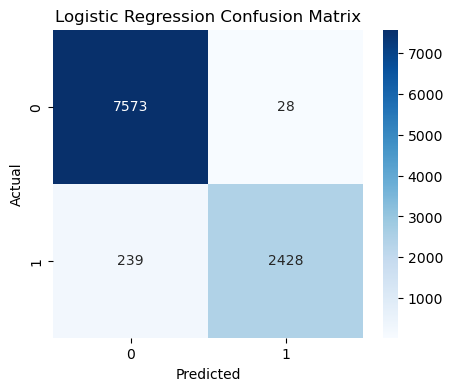

In [207]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

14. Random Forest

In [208]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=20, n_estimators=300, random_state=42)

Random Forest Evaluation

In [209]:
print("Accuracy :", accuracy_score(y_test,y_pred_rf))
print("Precision:", precision_score(y_test,y_pred_rf))
print("Recall   :", recall_score(y_test,y_pred_rf))
print("F1 Score :", f1_score(y_test,y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test,y_prob_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test,y_pred_rf))

Accuracy : 0.9888975457732762
Precision: 1.0
Recall   : 0.9572553430821147
F1 Score : 0.9781609195402299
ROC AUC  : 0.9996395003972747

Confusion Matrix
[[7601    0]
 [ 114 2553]]


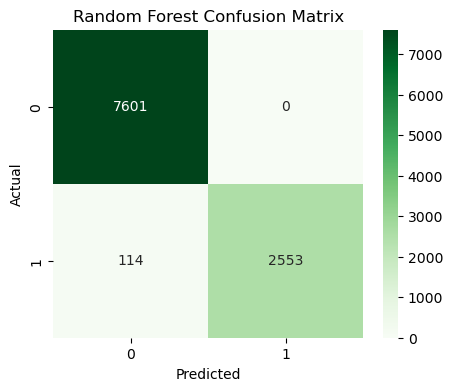

In [210]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [214]:
imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

imp = imp.sort_values(
    "Importance",
    ascending=False
)

print(imp.head(10))

                 Feature  Importance
0           Credit_Score    0.756698
14               enq_L3m    0.110814
16         enq_intensity    0.037951
15          delinq_ratio    0.023556
13               tot_enq    0.021445
10  num_times_delinquent    0.019000
8             Secured_TL    0.006584
11     num_times_30p_dpd    0.005171
1                    AGE    0.004835
3               Total_TL    0.004220


15. Feature Importance

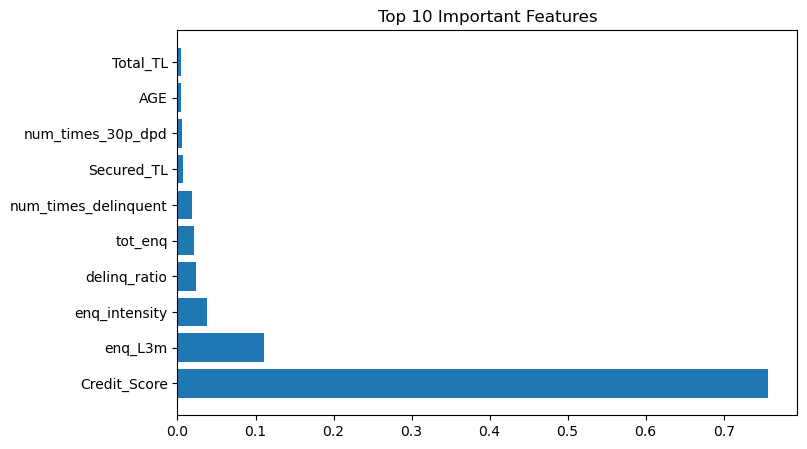

In [215]:
import matplotlib.pyplot as plt

top10 = imp.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.title("Top 10 Important Features")

plt.show()

16. Business Insights

Business Insights

1. Credit Score is the strongest predictor of default.

2. Customers with high enquiry activity
   have higher probability of default.

3. Customers with multiple delinquencies
   show significantly higher risk.

4. Unsecured loan exposure increases
   credit risk.

5. Recent enquiries are strong indicators
   of future default behaviour.

Business Insights

1. Credit Score emerged as the most influential factor in predicting customer default risk.

2. Customers with frequent credit enquiries (tot_enq, enq_L3m) exhibited higher probability of loan default.

3. Higher delinquency ratios were strongly associated with risky borrower behaviour.

4. Customers having multiple 30+ DPD and 60+ DPD instances showed increased default likelihood.

5. Unsecured loan exposure contributed more towards credit risk compared to secured loans.

6. The Random Forest model successfully identified high-risk customers with high recall, helping reduce potential credit losses.

7. The model can support loan approval, risk-based pricing, and early warning systems in retail lending.

17. Model Saving

In [216]:
import joblib

joblib.dump(
    rf,
    "credit_risk_model.pkl"
)

print("Model Saved")

Model Saved


In [218]:
import os

os.listdir()

['.ipynb_checkpoints',
 'app.py',
 'credit_risk_model.pkl',
 'External_Cibil_Dataset.xlsx',
 'Internal_Bank_Dataset.xlsx',
 'model.ipynb']